# Analyzing the Impact of Recession on Automobile Sales
---
### Course 8 - Data Visualization with Python - Final Project
#### Christian Jelo R. Artoza
#### May 10, 2026

## Overview

The task was to analyze historical data and provide insights on how automobile sales were affected during times of recession. A of number of charts/plots were provided to visualize the data and make it easy to understand the analysis.

## About the dataset
The dataset includes historical data on automobile sales during recession periods.
- recession period 1 - year 1980
- recession period 2 - year 1981 to 1982
- recession period 3 - year 1991
- recession period 4 - year 2000 to 2001
- recession period 5 - year end 2007 to mid 2009
- recession period 6 - year 2020 -Feb to April (Covid-19 Impact)

This dataset was artificially created for the purpose of this assignment only. No real data has been used.

## Data Description
The dataset includes the following variables:
- `Date`: The month end date of sales observation.
- `Recession`: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
- `Automobile_Sales`: The number of vehicles sold during the period.
- `GDP`: The per capita GDP value in USD.
- `Unemployment_Rate`: The monthly unemployment rate.
- `Consumer_Confidence`: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
- `Seasonality_Weight`: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods.
    - A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches).
    - A value less than 1 suggests lower-than-average sales due to seasonal slowdowns.A value around 1 means the season has neutral or average effect on sales.

- `Price`: The average vehicle price during the period.
- `Advertising_Expenditure`: The advertising expenditure of the company.
- `Vehicle_Type`: The type of vehicles sold; Supperminicar, Smallfamiliycar, Mediumfamilycar, Executivecar, Sports.
- `Competition`: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
- `Month`: Month of the observation extracted from Date.
- `Year`: Year of the observation extracted from Date.

The Project was completed in 2 Parts:
- Part 1: Visualizations using Matplotlib
- Part 2: Dashboard using Plotly and Dash

## Part 1: Visualizations using Matplotlib, Seaborn, & Folium

### Importing Required Libraries and the Dataset


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import folium
import calendar
import requests
from IPython.display import JSON
from datetime import date, timedelta

%matplotlib inline
mpl.style.use(['seaborn-v0_8'])

/Users/jelo/anaconda3/envs/IBM-DS/lib/python3.14/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Import dataset
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv'
df = pd.read_csv(url)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2112 non-null   object 
 1   Year                     2112 non-null   int64  
 2   Month                    2112 non-null   object 
 3   Recession                2112 non-null   int64  
 4   Consumer_Confidence      2112 non-null   float64
 5   Seasonality_Weight       2112 non-null   float64
 6   Price                    2112 non-null   int64  
 7   Advertising_Expenditure  2112 non-null   float64
 8   Competition              2112 non-null   int64  
 9   GDP                      2112 non-null   float64
 10  Growth_Rate              2112 non-null   float64
 11  unemployment_rate        2112 non-null   float64
 12  Automobile_Sales         2112 non-null   float64
 13  Vehicle_Type             2112 non-null   object 
 14  City                    

### Line Chart
I created a line chart to show how the average automobile sales fluctuate from year to year.

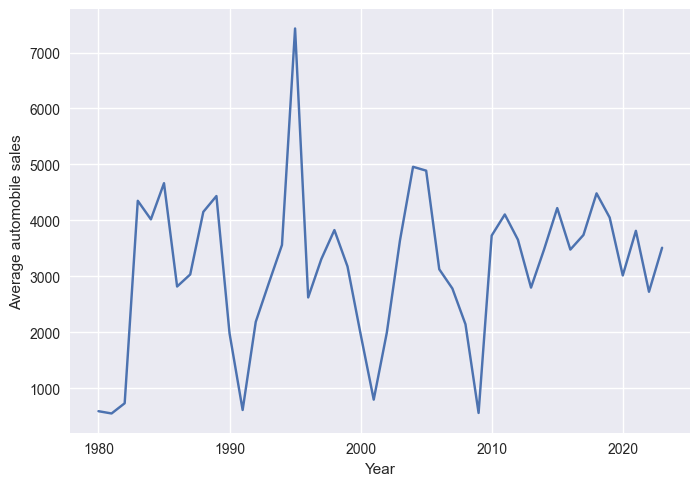

In [4]:
df.groupby('Year')['Automobile_Sales'].mean().plot()

plt.xlabel('Year')
plt.ylabel('Average automobile sales')
plt.show()

To get a better read on when the recession periods occured, I updated the x-ticks of the line chart to include all years, annotated the chart to show two years of recession, and set the title as 'Automobile Sales during Recession'.

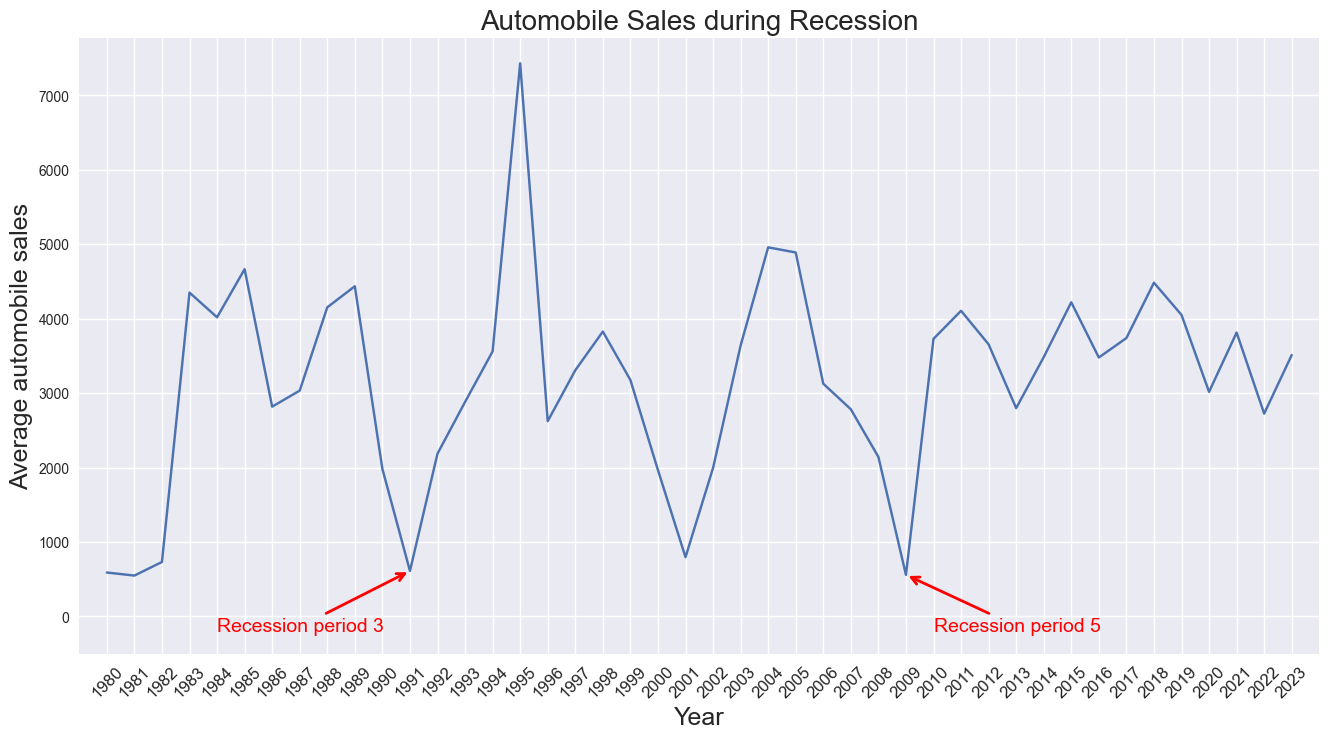

In [5]:
df.groupby('Year')['Automobile_Sales'].mean().plot(figsize=(16,8))

plt.title('Automobile Sales during Recession', fontsize=20)
plt.xticks(df['Year'].unique(), rotation=45, fontsize=12) # Update x-ticks to include all years
plt.xlabel('Year', fontsize=18)
plt.ylabel('Average automobile sales', fontsize=18)
plt.xlim(left = 1979, right = 2024)
plt.ylim(bottom = -500) #adjust y-axis limit to fit annotations

# Annotate automobile sales in 1991 -- Recession period 3.
plt.annotate(
    text = 'Recession period 3',
    fontsize = 14,
    xy = (1991, df.groupby('Year')['Automobile_Sales'].mean().loc[1991]),
    xytext = (1984, -200),
    color='red',
    arrowprops = dict(
        arrowstyle = '->',
        connectionstyle = 'arc3',
        color = 'red',
        lw = 2
    )
)
# Annotate automobile sales in 2009 -  lowest average sales in 5th recession period
plt.annotate(
    text = 'Recession period 5',
    fontsize = 14,
    xy = (2009, df.groupby('Year')['Automobile_Sales'].mean().loc[2009]),
    xytext = (2010, -200),
    color='red',
    arrowprops = dict(
        arrowstyle = '->',
        connectionstyle = 'arc3',
        color = 'red',
        lw = 2
    )
)
plt.show()

### Advertising Expenditures and Automobile Sales during Non-Recession Periods

I determined the correlation between trends in advertising expenditures and automobile sales during non-recession periods. I used a scatter plot to visualize the relationship and to gain some insights.

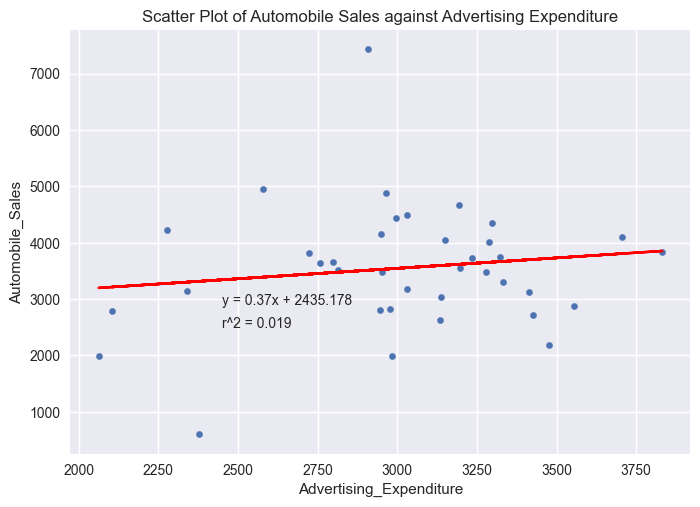

In [23]:
# Get data during non-recession periods
df_non_rec = df.loc[lambda df:
                        ((df['Date'] >= '1983-01-01') & (df['Date'] < '1991-01-01')) | 
                        ((df['Date'] >= '1992-01-01') & (df['Date'] < '2000-01-01')) |
                        ((df['Date'] >= '2002-01-01') & (df['Date'] < '2008-01-01')) |
                        ((df['Date'] >= '2009-07-01') & (df['Date'] < '2020-02-01')) |
                        ((df['Date'] >= '2020-05-01'))
                        ]
df_non_rec_grouped = df_non_rec.groupby('Year')[['Advertising_Expenditure', 'Automobile_Sales']].mean()
# Determine best-fit line
x = df_non_rec_grouped['Advertising_Expenditure']
y = df_non_rec_grouped['Automobile_Sales']
fit = np.polyfit(x, y, deg=1)
rsq = np.round(np.corrcoef(x,y)[0,1]**2,3)

# Create scatter plot
df_non_rec_grouped.plot(
    kind = 'scatter',
    x = 'Advertising_Expenditure',
    y = 'Automobile_Sales',
)

plt.plot(x, fit[0] * x + fit[1], color='red')
plt.annotate(
    text = f'y = {np.round(fit[0],3)}x + {np.round(fit[1],3)}',
    xy = (1999, 3200),
    xytext = (2450,2900)
)
plt.annotate(
    text = f'r^2 = {rsq}',
    xy = (1999, 3100),
    xytext = (2450,2500)
)

plt.title('Scatter Plot of Automobile Sales against Advertising Expenditure')
plt.show()

The plot shows a weak linear relationship between the advertising expenditure and automobile sales. Furthermore, the correlation coefficient r^2 is 0.019, indicating a weak correlation. Therefore, it can be said that advertising expenditure is not a good predictor of automobile sales.

### Sales trend during a recession and a non-recession period

In [24]:
df_non_rec.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
138,1983-01-31,1983,Jan,0,87.49,0.45,32048,2943.0,8,22.29,-1.33,3.2,288.0,MediumFamilyCar,Illinois
139,1983-01-31,1983,Jan,0,87.49,0.37,58002,2943.0,8,22.29,-1.33,3.2,308.0,ExecutiveCar,Illinois
140,1983-01-31,1983,Jan,0,87.49,0.42,15526,2943.0,8,22.29,-1.33,3.2,309.0,SuperMiniCar,Illinois
141,1983-02-28,1983,Feb,0,126.06,0.44,18224,4621.0,4,12.82,-1.12,2.4,1874.0,SuperMiniCar,Georgia
142,1983-02-28,1983,Feb,0,126.06,0.37,36233,4621.0,4,12.82,-1.12,2.4,1922.0,MediumFamilyCar,Georgia


In [42]:
df_rec = df.drop(df_non_rec.index)
df_rec['Rec_or_NonRec'] = 'Rec'
df_non_rec['Rec_or_NonRec'] = 'NonRec'

df_new = pd.concat([df_rec, df_non_rec])

/var/folders/46/z5gn_np13nb59ypsfdq54w4r0000gs/T/ipykernel_39503/1119704427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_rec['Rec_or_NonRec'] = 'NonRec'


In [43]:
df_new['Vehicle_Type'].value_counts()

Vehicle_Type
Sports             431
SmallFamilyCar     429
ExecutiveCar       421
MediumFamilyCar    418
SuperMiniCar       413
Name: count, dtype: int64

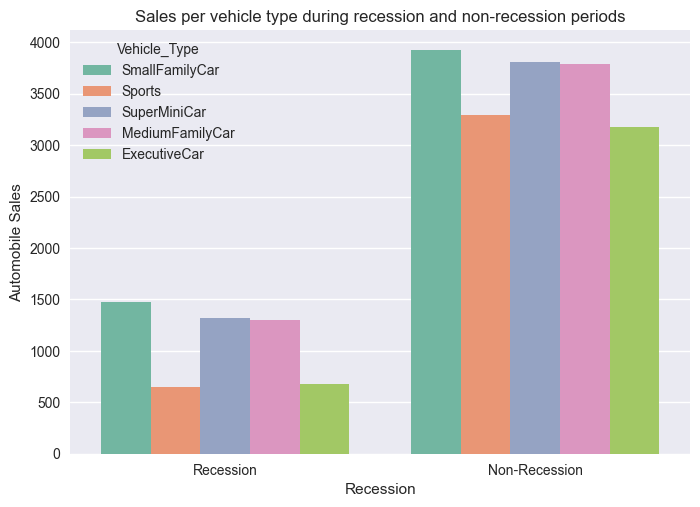

In [58]:
sns.barplot(
    hue = 'Vehicle_Type',
    y = 'Automobile_Sales',
    x = 'Rec_or_NonRec',
    data = df_new,
    errorbar = None,
    palette = 'Set2'
)
plt.title('Sales per vehicle type during recession and non-recession periods')
plt.xticks(ticks = [0,1], labels=['Recession','Non-Recession'])
plt.xlabel('Recession')
plt.ylabel('Automobile Sales')
plt.show()

Based on the above plot, frequency of sales are higher during non-recession periods by a significant amount. It is also notable that fewer sports cars and executive cars were sold during recession periods; agreeing with the fact that they cost more, and would sell harder at a time of recession. 